Text(0.5, 1.0, 'Canal Azul')

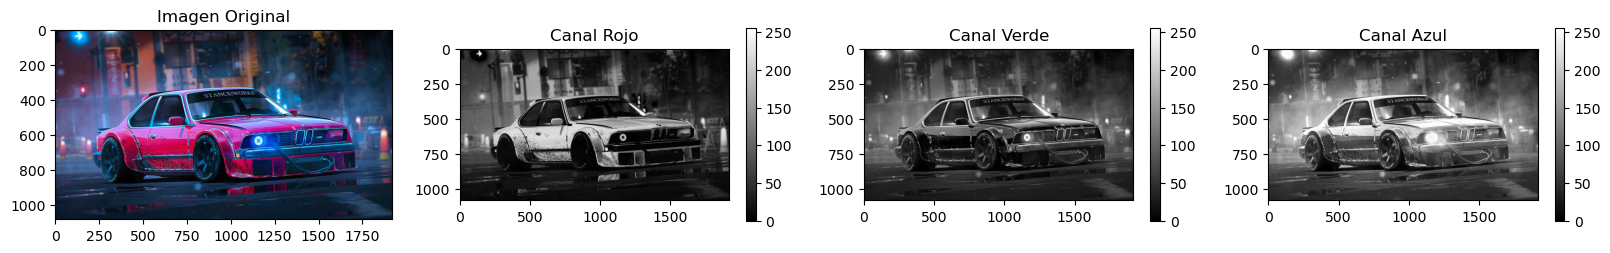

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img= cv2.imread('BMW_635.jpg')
img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1,4,figsize=(20,5))

axs[0].imshow(img_RGB)
axs[0].set_title('Imagen Original')

fig_img=axs[1].imshow(img_RGB[...,0], cmap='gray')
fig.colorbar(fig_img, ax=axs[1],shrink=0.5)
axs[1].set_title('Canal Rojo')

fig_img=axs[2].imshow(img_RGB[...,1], cmap='gray')
fig.colorbar(fig_img, ax=axs[2],shrink=0.5)
axs[2].set_title('Canal Verde')

fig_img=axs[3].imshow(img_RGB[...,2], cmap='gray')
fig.colorbar(fig_img, ax=axs[3],shrink=0.5)
axs[3].set_title('Canal Azul')

In [2]:
img_RGB[:3,:3,:3]

array([[[10, 14, 25],
        [10, 14, 25],
        [10, 14, 25]],

       [[10, 14, 25],
        [10, 14, 25],
        [10, 14, 25]],

       [[10, 14, 25],
        [10, 14, 25],
        [ 8, 15, 25]]], dtype=uint8)

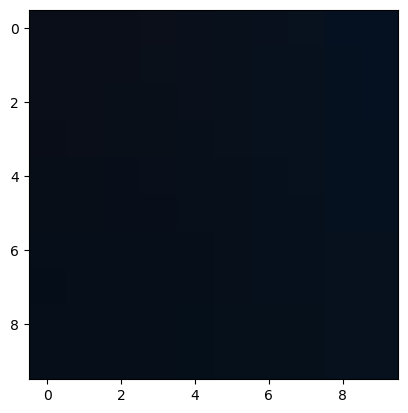

In [3]:
plt.imshow(img_RGB[:10,:10])

In [ ]:
cv2.imwrite('imagen.png',img_RGB)#Guardar con OPENCV
plt.imsave('imagen_nueva.jpg',cv2.cvtColor(img, cv2.COLOR_BGR2RGB))#Guardar con PYPLOT

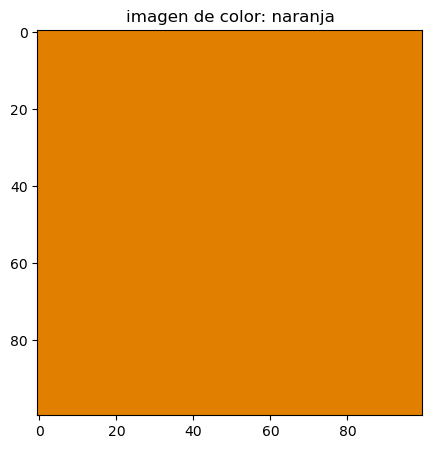

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 5)
size_imagen=100
R=np.ones((size_imagen,size_imagen))*225
G=np.ones((size_imagen,size_imagen))*128
B=np.ones((size_imagen,size_imagen))*0

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('imagen de color: naranja')
plt.show()

Escala de grises y profundidad de colores

Profundidad del color : uint16


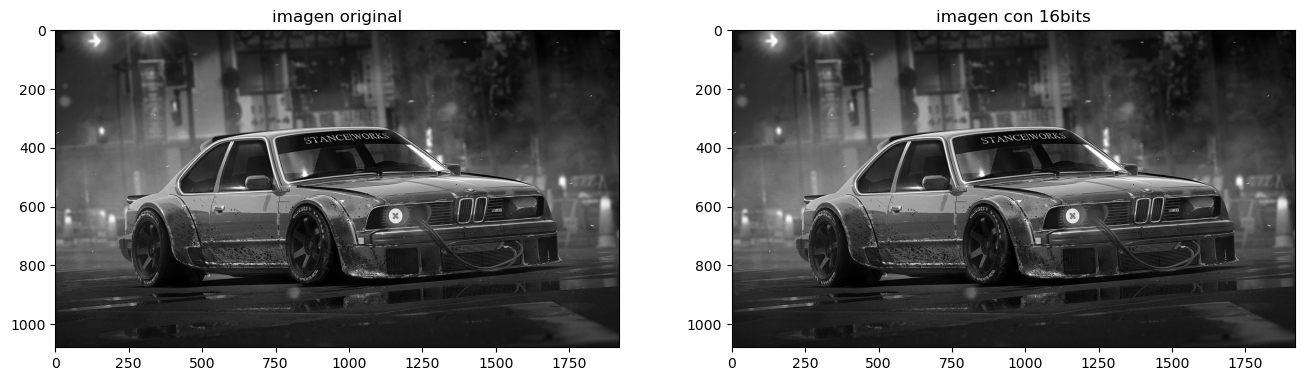

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img= cv2.imread('BMW_635.jpg',cv2.IMREAD_GRAYSCALE)
#valores inicialess de profundidad de color
original= img.dtype

#transformando imagen a 16 bits
img16bits=np.uint16(img)
img_new=img16bits.dtype
print('Profundidad del color :' ,img_new)

#guardado con cv2
cv2.imwrite('imagen.png',img_RGB)#Guardar con OPENCV
#guardado con pyplot
plt.imsave('imagen_nueva.jpg',cv2.cvtColor(img, cv2.COLOR_BGR2RGB))#Guardar con PYPLOT
#imagen estable tratada


plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.title('imagen original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('imagen con 16bits')
plt.imshow(img16bits, cmap='gray')

C:\Users\ASUS ROG\AppData\Local\Temp\ipykernel_114256\2466406070.py:36: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0]=60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


Text(0.5, 1.0, 'Canal Value')

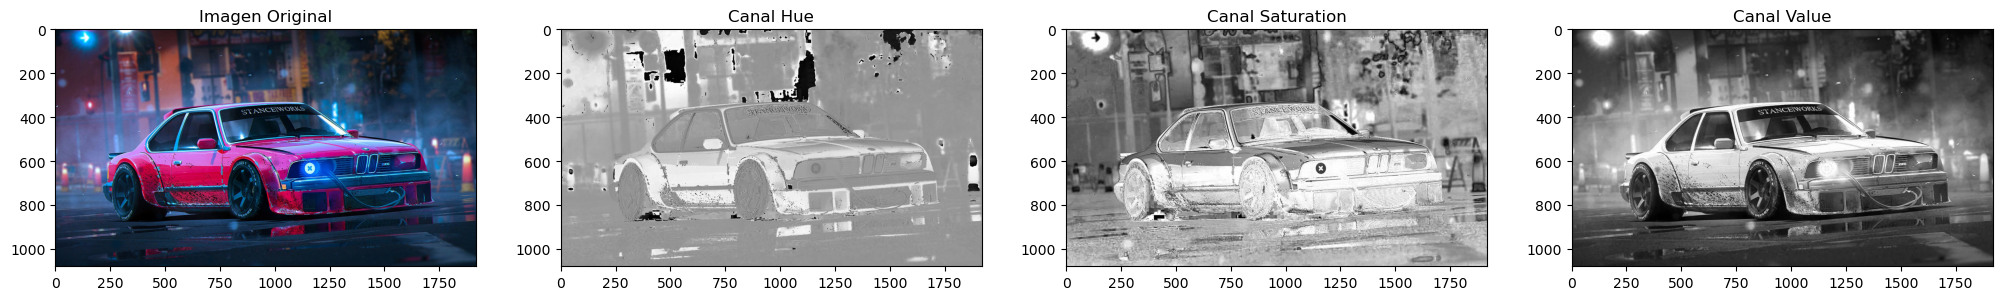

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen=cv2.imread('BMW_635.jpg')
img=cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB) 

def RGB2HSV(img):
    img=img.astype(np.float32)
    img=img/255.0
    new_img=np.zeros_like(img)

    maxChanel=np.argmax(img, axis=2)
    maxValue=np.amax(img, axis=2)
    minChanel=np.argmin(img, axis=2)
    minValue=np.amin(img, axis=2)

    #Calculo de value
    new_img[...,2]=maxValue

    #Calculo de saturation

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1]=0
            elif maxValue[i,j] !=0:
                new_img[i,j,1]=(new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #Calculo de Hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3==img[i,j,0]:
                new_img[i,j,0]=0
            elif maxChanel[i,j]==0: #rojo
                new_img[i,j,0]=60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==1: #verde
                new_img[i,j,0]=120+60*((img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==2: #azul
                new_img[i,j,0]=240+60*((img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j]))
        img2=new_img[...,0]<0
        new_img[img2,0]=new_img[img2,0]+360  #trabajamos con grados y no se puede sobrepasar los 360 grados
    return new_img

hsv_img=RGB2HSV(img)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)

axs[0].set_title('Imagen Original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)


axs[1].set_title('Canal Hue')
fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)


axs[2].set_title('Canal Saturation')
fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)


axs[3].set_title('Canal Value')



Text(0.5, 1.0, 'Canal Value')

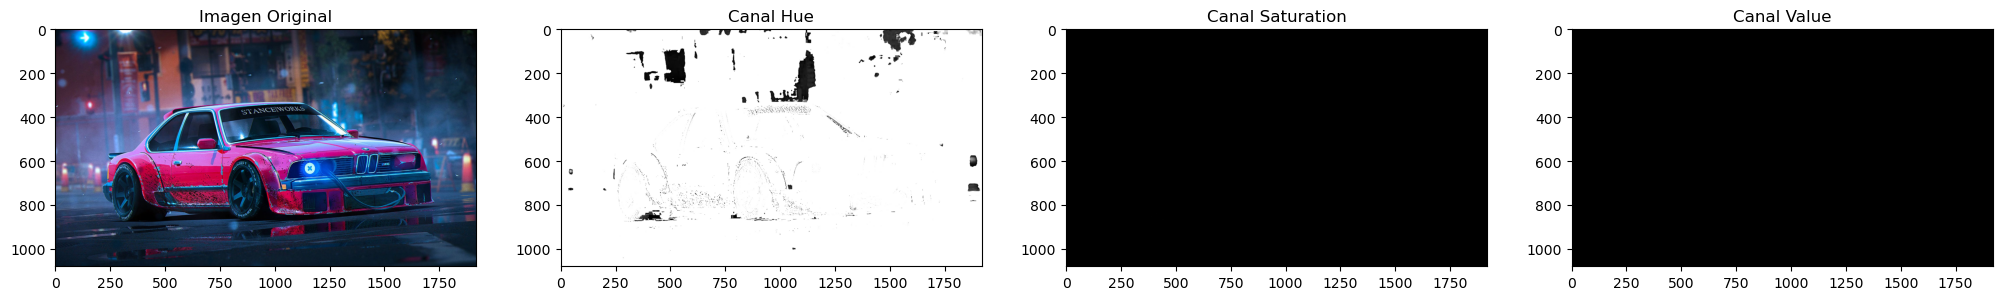

In [6]:
hsv_img_cv2=cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)

axs[0].set_title('Imagen Original')
fig_img=axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=179)


axs[1].set_title('Canal Hue')
fig_img=axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=255)


axs[2].set_title('Canal Saturation')
fig_img=axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=255)


axs[3].set_title('Canal Value')

Foto 1 guardada en HSV)


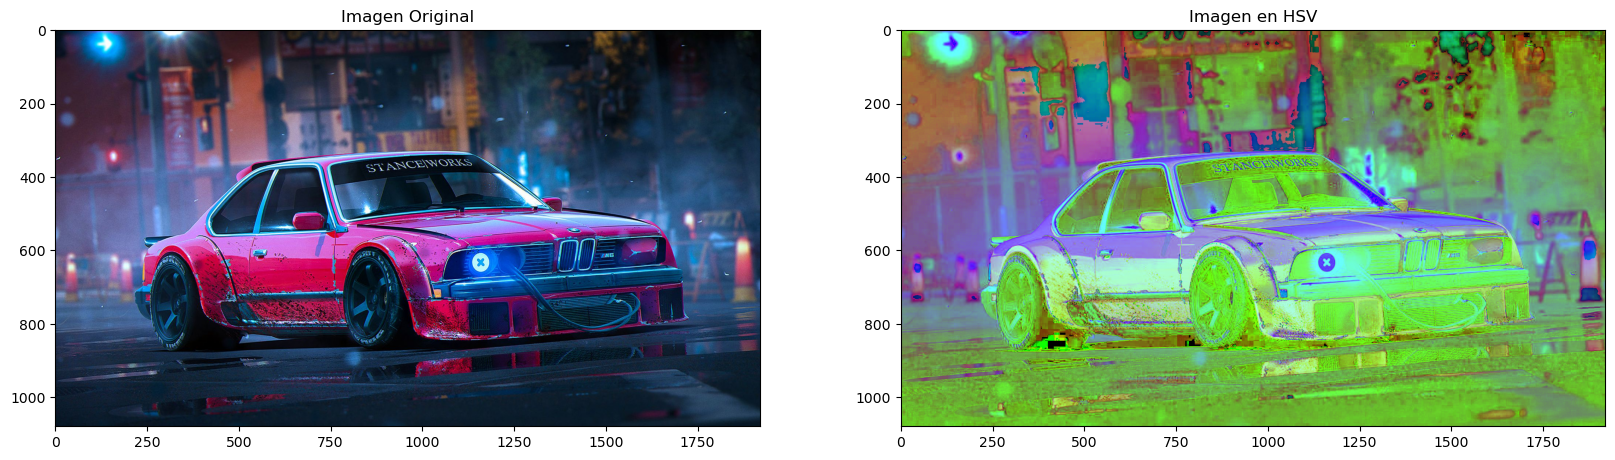

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rgb = cv2.cvtColor(cv2.imread('BMW_635.jpg', cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig,axs=plt.subplots(1,2,figsize=(20,10))
axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')
axs[1].imshow(img_hsv)
axs[1].set_title('Imagen en HSV')

#Guardar la imagen HSV con OPENCV
#cv2.imwrite('Img_hsv.jpg', img_hsv)
#print("Foto 1 guardada en HSV)")

Text(0.5, 1.0, 'Canal Azul')

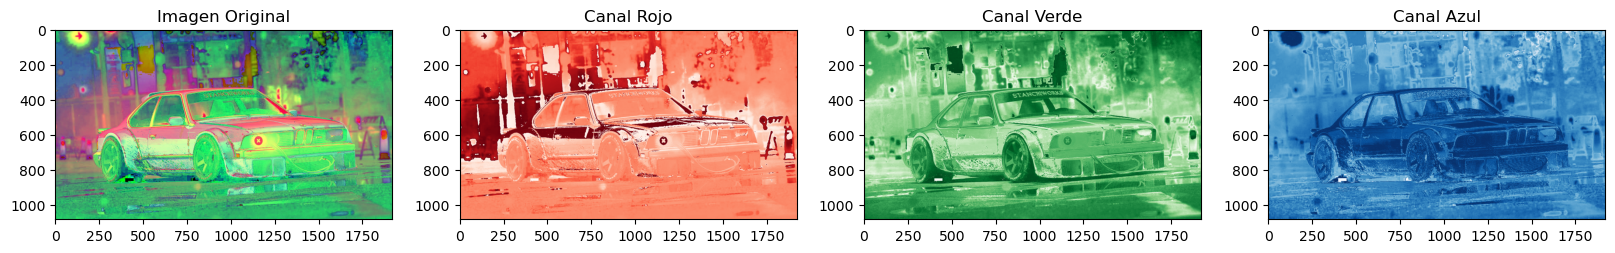

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_bgr = cv2.imread('Img_hsv.jpg', cv2.IMREAD_COLOR)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

def HSV2RGB(img):
    img = img.astype(np.float32)
    h = img[..., 0] / 360.0
    s = img[..., 1] / 255.0
    v = img[..., 2] / 255.0
    new_img = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if s[i,j] == 0:
                new_img[i,j,:] = v[i,j]
            else:
                c = v[i,j] * s[i,j]
                x = c * (1 - abs((h[i,j] * 6) % 2 - 1))
                m = v[i,j] - c
                hue_sector = h[i,j] * 6
                if 0 <= hue_sector < 1:
                    r, g, b = c, x, 0
                elif 1 <= hue_sector < 2:
                    r, g, b = x, c, 0
                elif 2 <= hue_sector < 3:
                    r, g, b = 0, c, x
                elif 3 <= hue_sector < 4:
                    r, g, b = 0, x, c
                elif 4 <= hue_sector < 5:
                    r, g, b = x, 0, c
                else:
                    r, g, b = c, 0, x
                new_img[i,j,:] = np.array([r + m, g + m, b + m]) * 255
    return np.clip(new_img, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axs[0].set_title('Imagen Original')

axs[1].imshow(img_hsv[..., 0], cmap='Reds', vmin=0, vmax=179)
axs[1].set_title('Canal Rojo')

axs[2].imshow(img_hsv[..., 1], cmap='Greens', vmin=0, vmax=255)
axs[2].set_title('Canal Verde')

axs[3].imshow(img_hsv[..., 2], cmap='Blues', vmin=0, vmax=255)
axs[3].set_title('Canal Azul')




Text(0.5, 1.0, 'Imagen en RGB')

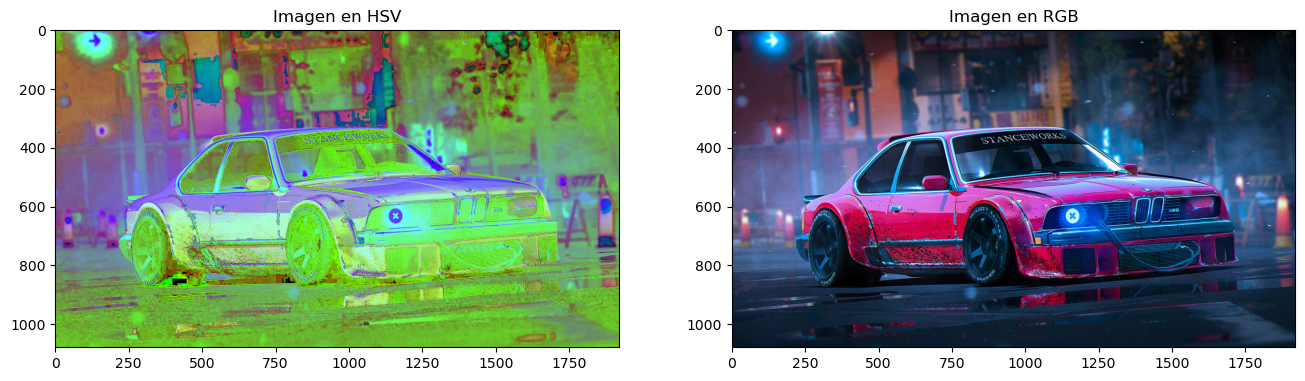

In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_bgr = cv2.imread('BMW_635.jpg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
img_rgb_reconstruida = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

axs[0].imshow(img_hsv)
axs[0].set_title('Imagen en HSV')

axs[1].imshow(img_rgb_reconstruida)
axs[1].set_title('Imagen en RGB')

